In [ ]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from pillow_heif import register_heif_opener

register_heif_opener()
np.random.seed(42)
random.seed(42)

In [ ]:
data_dir = r"D:\Imaan\Projects\Khilona(Color detector)\src\cleaned_dataset"
img_size = 64
epochs = 25
batch_size = 16
classes = ["blue", "purple", "yellow"]
belts = ["A", "B", "C"]
belt_map = {"blue": "A", "yellow": "B", "purple": "C"}

In [ ]:
def load_data(root, classes, img_size):
    X, y = [], []
    for idx, c in enumerate(classes):
        cls_dir = Path(root) / c
        files = list(cls_dir.glob("*.*"))
        print(f"Class {c}: {len(files)} images")
        
        for p in files:
            try:
                img = Image.open(p).convert("RGB").resize((img_size, img_size))
                X.append(np.asarray(img, dtype=np.float32) / 255.0)
                y.append(idx)
            except: pass
            
    X = np.array(X)
    y = to_categorical(np.array(y), num_classes=3)
    return X, y

X, y = load_data(data_dir, classes, img_size)

# Split into Train (70%), Validation (15%), and Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, shuffle=True)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization

model = Sequential([
    Input(shape=(64, 64, 3)),
    
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Flatten(),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# Save the trained model
model_save_path = r"D:\Imaan\Projects\Khilona(Color detector)\khilona_model.keras"
model.save(model_save_path)
print(f"Model successfully saved to: {model_save_path}")


In [ ]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"TRAINING ACCURACY: {train_acc:.4f}")
print(f"VALIDATION ACCURACY: {val_acc:.4f}")
print(f"TESTING ACCURACY: {test_acc:.4f}")

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)

Predicted Color: YELLOW
Assigned Conveyor Belt: B


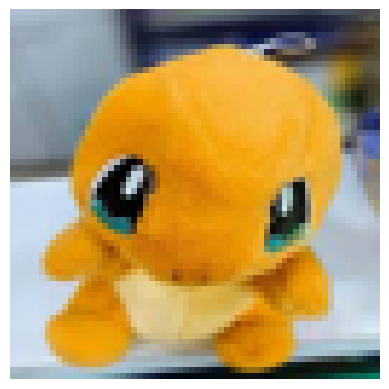

In [7]:
def predict_object(img_path):
    img = Image.open(img_path).convert("RGB").resize((img_size, img_size))
    x = np.asarray(img, dtype=np.float32) / 255.0
    x = np.expand_dims(x, axis=0)
    prediction = model.predict(x, verbose=0)
    pred_idx = np.argmax(prediction)
    confidence = prediction[0][pred_idx]
    
    if confidence < 0.6:
        pred_class = "unknown"
        belt = "None"
    else:
        pred_class = classes[pred_idx]
        belt = belts[pred_idx]

    print(f"Predicted Color: {pred_class.upper()} (Confidence: {confidence:.2f})")
    print(f"Assigned Conveyor Belt: {belt}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()

predict_object("C:\\Users\\imani\\Downloads\\yyyy.jpg")


In [10]:
import cv2

def run_live_camera():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not open camera.")
        return

    print("Starting Live Detection... Press 'q' to quit.")
    
    while True:
        ret, frame = cap.read()
        if not ret: break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized_frame = cv2.resize(rgb_frame, (img_size, img_size))
        input_array = np.expand_dims(resized_frame / 255.0, axis=0)

 
        prediction = model.predict(input_array, verbose=0)
        pred_idx = np.argmax(prediction)
        confidence = prediction[0][pred_idx]

        if confidence < 0.6:
            pred_class = "unknown"
            belt = "None"
        else:
            pred_class = classes[pred_idx]
            belt = belts[pred_idx]

        label = f"{pred_class.upper()} | Belt: {belt} | {confidence:.2f}"
        cv2.putText(frame, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
        cv2.imshow('KHILONA Live Detection', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# To run camera, uncomment below:
run_live_camera()


Starting Live Detection... Press 'q' to quit.
